In [1]:
library(mlr)

Loading required package: ParamHelpers



In [2]:
library(tidyverse)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
data(wine, package = 'HDclassif')

In [4]:
wine

class,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045


In [5]:
winetib<-as_tibble(wine)

In [6]:
names(winetib) <- c(
    'Class',
    'Alco',
    'Malic',
    'Ash',
    'Alk',
    'Mag',
    'Phe',
    'Flav','Non_flav','Proan','Col','Hue','OD','Prol')

In [7]:
winetib$Class <- as.factor(winetib$Class)

In [8]:
winetib

Class,Alco,Malic,Ash,Alk,Mag,Phe,Flav,Non_flav,Proan,Col,Hue,OD,Prol
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045


In [9]:
#viendo las propiedades quieres ver de que viñedo viene el vino?

In [10]:
wineuntidy<-gather(winetib, 'Variable','Value', -Class)
wineuntidy

Class,Variable,Value
<fct>,<chr>,<dbl>
1,Alco,14.23
1,Alco,13.20
1,Alco,13.16
1,Alco,14.37
1,Alco,13.24
1,Alco,14.20
1,Alco,14.39
1,Alco,14.06
1,Alco,14.83


Saving 6.67 x 6.67 in image


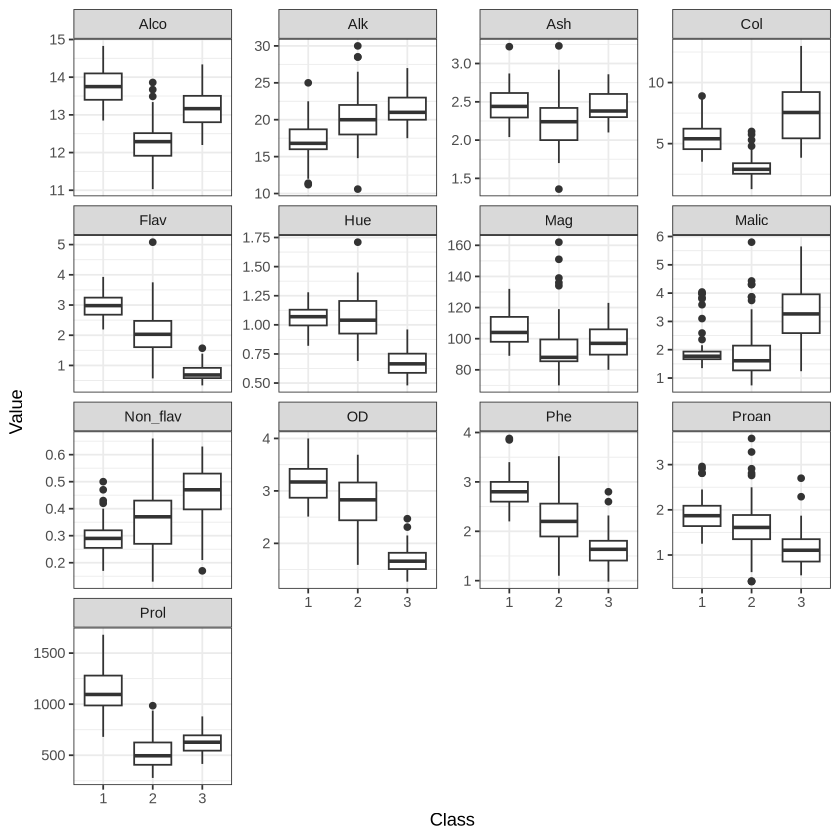

In [11]:
(
    ggplot(wineuntidy, aes(Class,Value)) + 
    facet_wrap(~Variable, scales = 'free_y') + 
    geom_boxplot() + 
    theme_bw()
)
ggsave('all.png')

In [12]:
task<-makeClassifTask(data = winetib,target = 'Class')

Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
“Provided data is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [13]:
lda<-makeLearner('classif.lda')

In [14]:
lda

Learner classif.lda from package MASS
Type: classif
Name: Linear Discriminant Analysis; Short name: lda
Class: classif.lda
Properties: twoclass,multiclass,numerics,factors,prob
Predict-Type: response
Hyperparameters: 


In [15]:
ldamodel<-train(lda, task)

In [16]:
ldamodel

Model for learner.id=classif.lda; learner.class=classif.lda
Trained on: task.id = winetib; obs = 178; features = 13
Hyperparameters: 

In [17]:
ldamodeldata<-getLearnerModel(ldamodel)

In [18]:
ldaPreds<-predict(ldamodeldata)$x

In [19]:
#predict(newdata = )

In [20]:
head(ldaPreds)

,LD1,LD2
1,-4.700244,1.9791383
2,-4.301958,1.1704129
3,-3.420720,1.4291014
4,-4.205754,4.0028715
5,-1.509982,0.4512239
6,-4.518689,3.2131376


In [21]:
#si son los puntos mapeados al spacio ld1 y ld2
(
    winetib %>% 
    mutate(LD1 = ldaPreds[,1], LD2=ldaPreds[,2])
 
)

Class,Alco,Malic,Ash,Alk,Mag,Phe,Flav,Non_flav,Proan,Col,Hue,OD,Prol,LD1,LD2
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,-4.700244,1.9791383
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,-4.301958,1.1704129
1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,-3.420720,1.4291014
1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,-4.205754,4.0028715
1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,-1.509982,0.4512239
1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,-4.518689,3.2131376
1,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290,-4.527378,3.2691218
1,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295,-4.148348,3.1041177
1,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045,-3.860829,1.9533826


Saving 6.67 x 6.67 in image


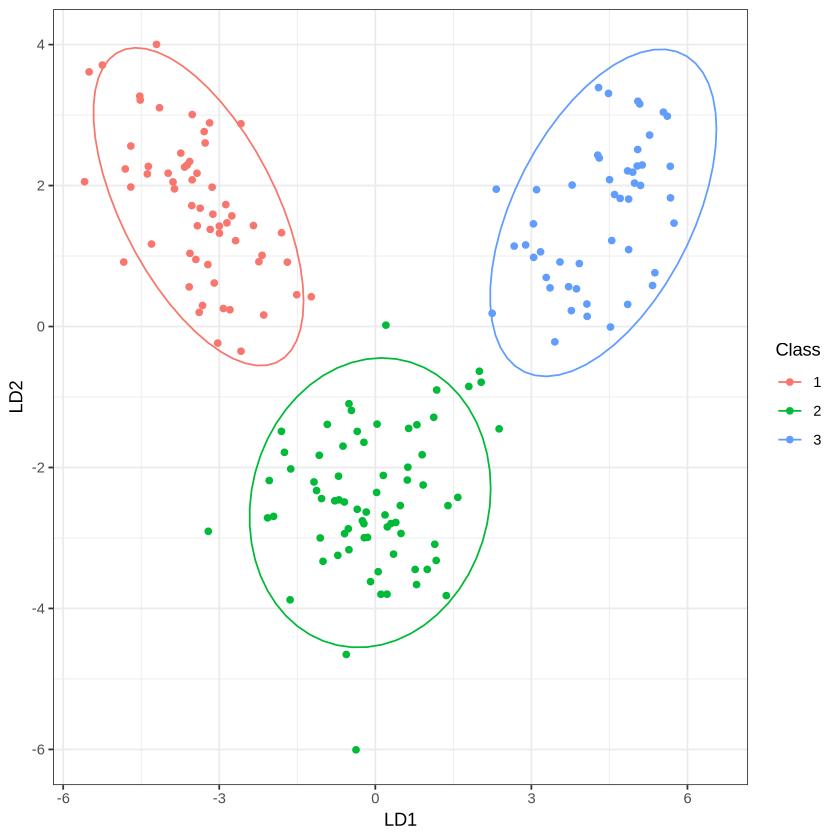

In [22]:
#estan projectadas a 2D dimensionality reduction
(
    winetib %>% 
    mutate(LD1 = ldaPreds[,1], LD2=ldaPreds[,2]) %>% 
    ggplot(aes(LD1,LD2, col = Class)) + 
    geom_point() + 
    stat_ellipse() + 
    theme_bw()
)
ggsave('projections.png')

In [23]:
qda<-makeLearner('classif.qda')

In [24]:
qdamodel<-train(qda,task)

In [25]:
kfold<-makeResampleDesc(
    method = 'RepCV', 
    folds=10, 
    reps=50, 
    stratify = TRUE
)

In [26]:
ldacv<-resample(learner = lda, task, kfold, list(mmce,acc))

Resampling: repeated cross-validation

Measures:             mmce      acc       

[Resample] iter 1:    0.0555556 0.9444444 

[Resample] iter 2:    0.0000000 1.0000000 

[Resample] iter 3:    0.0000000 1.0000000 

[Resample] iter 4:    0.0000000 1.0000000 

[Resample] iter 5:    0.0000000 1.0000000 

[Resample] iter 6:    0.0000000 1.0000000 

[Resample] iter 7:    0.0000000 1.0000000 

[Resample] iter 8:    0.0000000 1.0000000 

[Resample] iter 9:    0.0000000 1.0000000 

[Resample] iter 10:   0.0588235 0.9411765 

[Resample] iter 11:   0.0000000 1.0000000 

[Resample] iter 12:   0.0000000 1.0000000 

[Resample] iter 13:   0.0000000 1.0000000 

[Resample] iter 14:   0.0000000 1.0000000 

[Resample] iter 15:   0.0555556 0.9444444 

[Resample] iter 16:   0.0000000 1.0000000 

[Resample] iter 17:   0.1176471 0.8823529 

[Resample] iter 18:   0.0000000 1.0000000 

[Resample] iter 19:   0.0000000 1.0000000 

[Resample] iter 20:   0.0000000 1.0000000 

[Resample] iter 21:   0.0000000 1.000

In [27]:
ldacv

Resample Result
Task: winetib
Learner: classif.lda
Aggr perf: mmce.test.mean=0.0123302,acc.test.mean=0.9876698
Runtime: 3.45709

In [28]:
qdacv<-resample(learner = qda, task, kfold, list(mmce,acc))

Resampling: repeated cross-validation

Measures:             mmce      acc       

[Resample] iter 1:    0.0000000 1.0000000 

[Resample] iter 2:    0.0625000 0.9375000 

[Resample] iter 3:    0.0555556 0.9444444 

[Resample] iter 4:    0.0000000 1.0000000 

[Resample] iter 5:    0.0000000 1.0000000 

[Resample] iter 6:    0.0000000 1.0000000 

[Resample] iter 7:    0.0000000 1.0000000 

[Resample] iter 8:    0.0000000 1.0000000 

[Resample] iter 9:    0.0000000 1.0000000 

[Resample] iter 10:   0.0000000 1.0000000 

[Resample] iter 11:   0.0000000 1.0000000 

[Resample] iter 12:   0.0000000 1.0000000 

[Resample] iter 13:   0.1111111 0.8888889 

[Resample] iter 14:   0.0000000 1.0000000 

[Resample] iter 15:   0.0000000 1.0000000 

[Resample] iter 16:   0.0000000 1.0000000 

[Resample] iter 17:   0.0000000 1.0000000 

[Resample] iter 18:   0.0000000 1.0000000 

[Resample] iter 19:   0.0000000 1.0000000 

[Resample] iter 20:   0.0000000 1.0000000 

[Resample] iter 21:   0.0000000 1.000

In [29]:
qdacv

Resample Result
Task: winetib
Learner: classif.qda
Aggr perf: mmce.test.mean=0.0081023,acc.test.mean=0.9918977
Runtime: 3.25607

In [30]:
ldacv

Resample Result
Task: winetib
Learner: classif.lda
Aggr perf: mmce.test.mean=0.0123302,acc.test.mean=0.9876698
Runtime: 3.45709

In [31]:
calculateConfusionMatrix(ldacv$pred, relative = TRUE)

Relative confusion matrix (normalized by row/column):
        predicted
true     1           2           3           -err.-     
  1      1e+00/1e+00 7e-04/6e-04 0e+00/0e+00 7e-04      
  2      9e-03/1e-02 1e+00/1e+00 2e-02/2e-02 3e-02      
  3      0e+00/0e+00 7e-03/5e-03 1e+00/1e+00 7e-03      
  -err.-       0.011       0.006       0.023 0.01       


Absolute confusion matrix:
        predicted
true        1    2    3 -err.-
  1      2948    2    0      2
  2        33 3461   56     89
  3         0   18 2382     18
  -err.-   33   20   56    109

In [32]:
calculateConfusionMatrix(qdacv$pred, relative = TRUE)

Relative confusion matrix (normalized by row/column):
        predicted
true     1           2           3           -err.-     
  1      0.995/0.984 0.005/0.004 0.000/0.000 0.005      
  2      0.014/0.016 0.986/0.993 0.000/0.000 0.014      
  3      0.000/0.000 0.003/0.002 0.997/1.000 0.003      
  -err.-       0.016       0.007       0.000 0.008      


Absolute confusion matrix:
        predicted
true        1    2    3 -err.-
  1      2935   15    0     15
  2        49 3501    0     49
  3         0    8 2392      8
  -err.-   49   23    0     72

In [33]:
poisoned<-tibble(Alco = 13, Malic = 2, Ash = 2.2, Alk = 19, Mag = 100,
Phe = 2.3, Flav = 2.5, Non_flav = 0.35, Proan = 1.7,
Col = 4, Hue = 1.1, OD = 3, Prol = 750)
poisoned

Alco,Malic,Ash,Alk,Mag,Phe,Flav,Non_flav,Proan,Col,Hue,OD,Prol
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
13,2,2.2,19,100,2.3,2.5,0.35,1.7,4,1.1,3,750


In [34]:
predict(qdamodel, newdata = poisoned)

Warning message in predict.WrappedModel(qdamodel, newdata = poisoned):
“Provided data for prediction is not a pure data.frame but from class tbl_df, hence it will be converted.”


Prediction: 1 observations
predict.type: response
threshold: 
time: 0.00
  response
1        1

In [35]:
wineDiscr<-(
    winetib %>% 
    mutate(LD1 = ldaPreds[,1], LD2=ldaPreds[,2]) %>%
    select(Class,LD1,LD2)
)
wineDiscr

Class,LD1,LD2
<fct>,<dbl>,<dbl>
1,-4.700244,1.9791383
1,-4.301958,1.1704129
1,-3.420720,1.4291014
1,-4.205754,4.0028715
1,-1.509982,0.4512239
1,-4.518689,3.2131376
1,-4.527378,3.2691218
1,-4.148348,3.1041177
1,-3.860829,1.9533826


In [36]:
wineDiscrTask<-makeClassifTask(data = wineDiscr, target = 'Class')

Warning message in makeTask(type = type, data = data, weights = weights, blocking = blocking, :
“Provided data is not a pure data.frame but from class tbl_df, hence it will be converted.”


In [37]:
wineDiscrTask

Supervised task: wineDiscr
Type: classif
Target: Class
Observations: 178
Features:
   numerics     factors     ordered functionals 
          2           0           0           0 
Missings: FALSE
Has weights: FALSE
Has blocking: FALSE
Has coordinates: FALSE
Classes: 3
 1  2  3 
59 71 48 
Positive class: NA

In [38]:
knnParamSpace<-makeParamSet(makeDiscreteParam('k',values = 1:10))

In [39]:
gridSearch<-makeTuneControlGrid()

In [40]:
cvForTuning<-makeResampleDesc('RepCV',folds=10,reps=20)

In [41]:
tunedk<-tuneParams(
    'classif.knn', 
    task = wineDiscrTask, 
    resampling=cvForTuning,
    par.set = knnParamSpace,
    control=gridSearch
)

[Tune] Started tuning learner classif.knn for parameter set:

      Type len Def               Constr Req Tunable Trafo
k discrete   -   - 1,2,3,4,5,6,7,8,9,10   -    TRUE     -

With control class: TuneControlGrid

Imputation value: 1

[Tune-x] 1: k=1

[Tune-y] 1: mmce.test.mean=0.0058987; time: 0.0 min

[Tune-x] 2: k=2

[Tune-y] 2: mmce.test.mean=0.0064542; time: 0.0 min

[Tune-x] 3: k=3

[Tune-y] 3: mmce.test.mean=0.0053431; time: 0.0 min

[Tune-x] 4: k=4

[Tune-y] 4: mmce.test.mean=0.0033660; time: 0.0 min

[Tune-x] 5: k=5

[Tune-y] 5: mmce.test.mean=0.0036438; time: 0.0 min

[Tune-x] 6: k=6

[Tune-y] 6: mmce.test.mean=0.0025163; time: 0.0 min

[Tune-x] 7: k=7

[Tune-y] 7: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 8: k=8

[Tune-y] 8: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 9: k=9

[Tune-y] 9: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 10: k=10

[Tune-y] 10: mmce.test.mean=0.0000000; time: 0.0 min

[Tune] Result: k=10 : mmce.test.mean=0.0000000



In [42]:
tunedk

Tune result:
Op. pars: k=10
mmce.test.mean=0.0000000

In [43]:
knnTuningData<-generateHyperParsEffectData(tunedk)

In [44]:
knnTuningData

HyperParsEffectData:
Hyperparameters: k
Measures: mmce.test.mean
Optimizer: TuneControlGrid
Nested CV Used: FALSE
Snapshot of data:
  k mmce.test.mean iteration exec.time
1 1    0.005898693         1     0.427
2 2    0.006454248         2     0.431
3 3    0.005343137         3     0.444
4 4    0.003366013         4     0.442
5 5    0.003643791         5     0.431
6 6    0.002516340         6     0.432

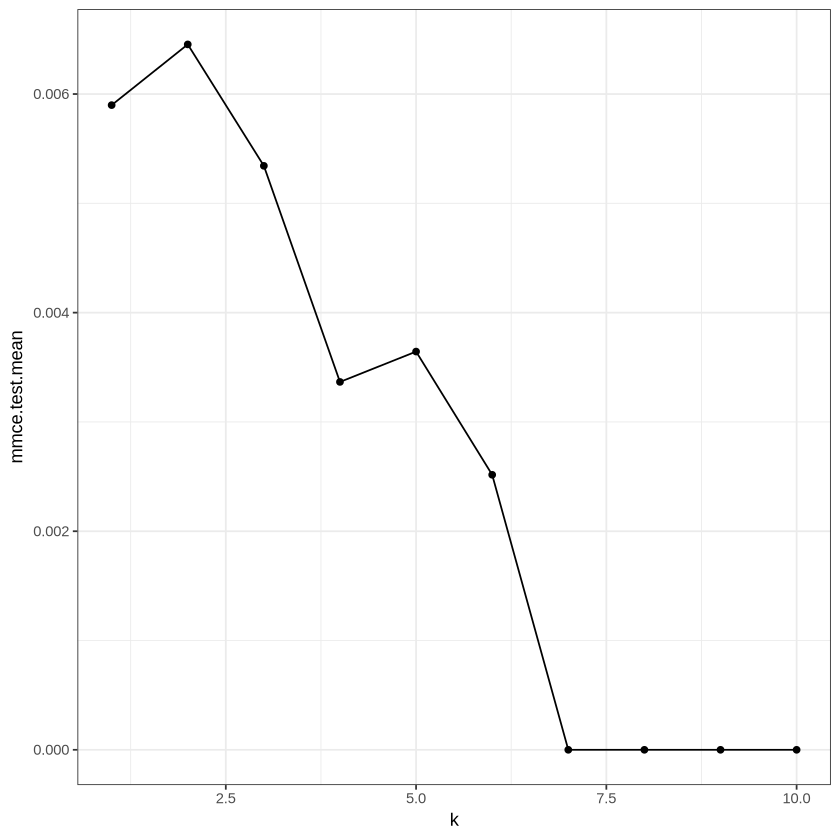

In [45]:
plotHyperParsEffect(
    knnTuningData, 
    x = 'k',
    y = 'mmce.test.mean', 
    plot.type = 'line') + theme_bw()

In [46]:
inner<-makeResampleDesc('CV')
outer<-makeResampleDesc('CV')

#utiliza el mejor k del inner y lo usa en el outer
knnWraper<-makeTuneWrapper(
    'classif.knn', 
    resampling = inner, 
    par.set = knnParamSpace,
    control = gridSearch
)

In [47]:
cvWithTuning<-resample(knnWraper, wineDiscrTask, resampling = outer, measures=list(mmce,acc))

Resampling: cross-validation

Measures:             mmce      acc       

[Tune] Started tuning learner classif.knn for parameter set:

      Type len Def               Constr Req Tunable Trafo
k discrete   -   - 1,2,3,4,5,6,7,8,9,10   -    TRUE     -

With control class: TuneControlGrid

Imputation value: 1

[Tune-x] 1: k=1

[Tune-y] 1: mmce.test.mean=0.0062500; time: 0.0 min

[Tune-x] 2: k=2

[Tune-y] 2: mmce.test.mean=0.0125000; time: 0.0 min

[Tune-x] 3: k=3

[Tune-y] 3: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 4: k=4

[Tune-y] 4: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 5: k=5

[Tune-y] 5: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 6: k=6

[Tune-y] 6: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 7: k=7

[Tune-y] 7: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 8: k=8

[Tune-y] 8: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 9: k=9

[Tune-y] 9: mmce.test.mean=0.0000000; time: 0.0 min

[Tune-x] 10: k=10

[Tune-y] 10: mmce.test.mean=0.0000000; t

In [48]:
cvWithTuning

Resample Result
Task: wineDiscr
Learner: classif.knn.tuned
Aggr perf: mmce.test.mean=0.0000000,acc.test.mean=1.0000000
Runtime: 3.90537

In [53]:
tunedknn<-setHyperPars(makeLearner('classif.knn'), par.vals = tunedk$x)

In [56]:
model<-train(tunedknn, wineDiscrTask)

In [59]:
#predict(model, newdata = poisoned)